<a href="https://colab.research.google.com/github/pakchirav/Data-Science-Practicum/blob/main/DS_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd

df = pd.read_csv("imputed_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  int64  
 1   Gender             25500 non-null  object 
 2   Glucose            25500 non-null  float64
 3   Blood_Pressure     25500 non-null  float64
 4   BMI                25500 non-null  float64
 5   Oxygen_Saturation  25500 non-null  float64
 6   LengthOfStay       25500 non-null  int64  
 7   Cholesterol        25500 non-null  float64
 8   Triglycerides      25500 non-null  float64
 9   HbA1c              25500 non-null  float64
 10  Smoking            25500 non-null  int64  
 11  Alcohol            25500 non-null  int64  
 12  Physical_Activity  25500 non-null  float64
 13  Diet_Score         25500 non-null  float64
 14  Family_History     25500 non-null  int64  
 15  Stress_Level       25500 non-null  float64
 16  Sleep_Hours        255

In [20]:
df['Smoking'] = df['Smoking'].astype('category')
df['Alcohol'] = df['Alcohol'].astype('category')
df['Family_History'] = df['Family_History'].astype('category')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                25500 non-null  int64   
 1   Gender             25500 non-null  object  
 2   Glucose            25500 non-null  float64 
 3   Blood_Pressure     25500 non-null  float64 
 4   BMI                25500 non-null  float64 
 5   Oxygen_Saturation  25500 non-null  float64 
 6   LengthOfStay       25500 non-null  int64   
 7   Cholesterol        25500 non-null  float64 
 8   Triglycerides      25500 non-null  float64 
 9   HbA1c              25500 non-null  float64 
 10  Smoking            25500 non-null  category
 11  Alcohol            25500 non-null  category
 12  Physical_Activity  25500 non-null  float64 
 13  Diet_Score         25500 non-null  float64 
 14  Family_History     25500 non-null  category
 15  Stress_Level       25500 non-null  float64 
 16  Slee

In [22]:
df.describe()

,Age,Glucose,Blood_Pressure,BMI,Oxygen_Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Physical_Activity,Diet_Score,Stress_Level,Sleep_Hours
count,25500.000000,25500.000000,25500.000000,25500.000000,25500.000000,25500.00000,25500.000000,25500.000000,25500.000000,25500.000000,25500.000000,25500.000000,25500.000000
mean,54.652667,123.552559,140.429416,28.474939,94.950878,4.40549,213.072891,176.910747,6.292121,3.807093,4.035195,5.921881,6.231123
std,15.940934,41.514092,21.137639,5.727344,3.742507,2.74404,33.616404,48.802188,1.318946,2.011850,1.821913,2.222386,1.188446
min,10.000000,20.320000,74.240000,7.670000,67.510000,1.00000,95.730000,-22.480000,3.280000,-3.680000,-1.750000,-2.070000,1.590000
25%,45.000000,96.230000,125.020000,24.590000,92.990000,3.00000,189.410000,141.407500,5.330000,2.360000,2.780000,4.380000,5.420000
50%,55.000000,110.475000,138.255000,28.050000,95.300000,4.00000,211.760000,173.540000,5.970000,3.590000,3.790000,5.900000,6.230000
75%,66.000000,136.370000,153.960000,31.830000,97.380000,5.00000,235.370000,208.422500,6.910000,5.080000,5.030000,7.442500,7.050000
max,89.000000,318.510000,226.380000,56.850000,110.070000,19.00000,355.270000,421.510000,12.360000,12.410000,12.060000,15.450000,10.350000


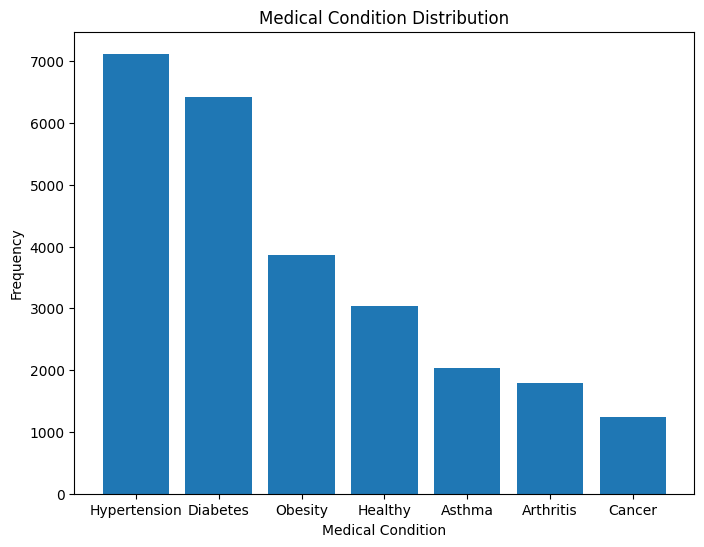

In [23]:
import matplotlib.pyplot as plt

medcon_count = df['Medical_Condition'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(medcon_count.index, medcon_count.values)
plt.xlabel('Medical Condition')
plt.ylabel('Frequency')
plt.title('Medical Condition Distribution')
plt.show()

In [24]:
X = df.drop('Medical_Condition', axis=1)
X = pd.get_dummies(X, columns=['Gender'])
X.head()

,Age,Glucose,Blood_Pressure,BMI,Oxygen_Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical_Activity,Diet_Score,Family_History,Stress_Level,Sleep_Hours,Gender_Female,Gender_Male
0,46,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,False,True
1,22,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,False,True
2,50,95.24,141.82,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,False,True
3,57,144.05,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,False,True
4,66,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,True,False


In [25]:
#convert to numpy array for sklearn
X = X.to_numpy()
Y = df['Medical_Condition'].to_numpy()

X.shape, Y.shape

((25500, 18), (25500,))

In [26]:
from sklearn.model_selection import train_test_split

#split into 80:20
#imbalance dataset => stratify
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify =Y, random_state=42)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((20400, 18), (5100, 18), (20400,), (5100,))

In [27]:
import pandas as pd
pd.Series(Y_train).value_counts()

,count
Hypertension,5696
Diabetes,5133
Obesity,3086
Healthy,2431
Asthma,1630
Arthritis,1437
Cancer,987


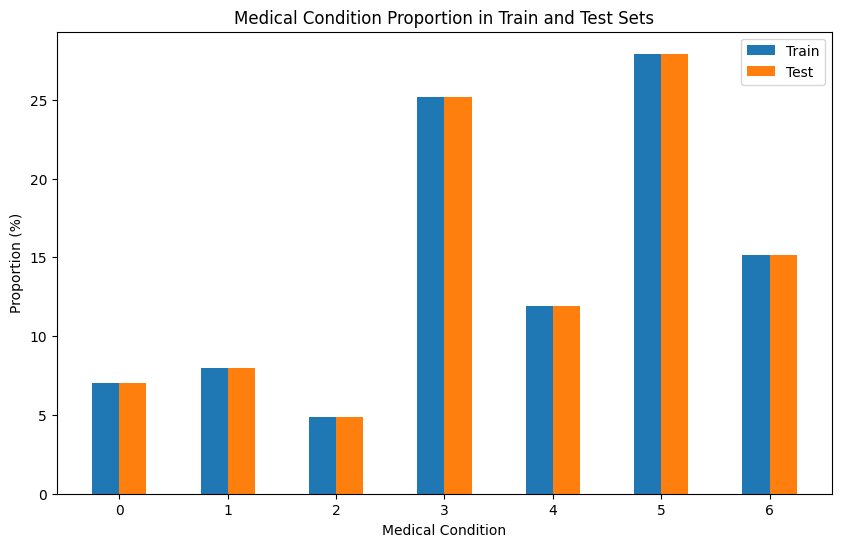

In [28]:
import numpy as np
from collections import Counter

#calculate label proportion
def calculate_proportions(y) :
  counter = Counter(y)
  total = sum(counter.values())
  proportions = {label : count / total*100 for label, count in counter.items()}
  return proportions

train_prop = calculate_proportions(Y_train)
test_prop = calculate_proportions(Y_test)

labels = sorted(set(Y_train))
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x-width/2, [train_prop.get(label, 0) for label in labels], width, label = 'Train')
ax.bar(x+width/2, [test_prop.get(label, 0) for label in labels], width, label = 'Test')

ax.set_xlabel('Medical Condition')
ax.set_ylabel('Proportion (%)')
ax.set_title('Medical Condition Proportion in Train and Test Sets')
ax.set_xticks(x)
ax.legend()

plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

SEED = 1

rforest = RandomForestClassifier(n_estimators=100, random_state=SEED)
rforest.fit(X_train, Y_train)

RandomForestClassifier(random_state=1)

In [30]:
from sklearn.metrics import classification_report

Y_pred = rforest.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print('{:s} : {:.3f}'.format('Accuracy', accuracy))
print(classification_report(Y_test, Y_pred))

Accuracy : 0.907
              precision    recall  f1-score   support

   Arthritis       0.80      0.59      0.68       359
      Asthma       0.91      0.87      0.89       407
      Cancer       0.98      0.98      0.98       247
    Diabetes       0.95      0.95      0.95      1284
     Healthy       0.99      0.99      0.99       608
Hypertension       0.86      0.93      0.89      1424
     Obesity       0.88      0.88      0.88       771

    accuracy                           0.91      5100
   macro avg       0.91      0.88      0.89      5100
weighted avg       0.91      0.91      0.91      5100



In [31]:
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight='balanced')
rf.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

In [32]:
Y_pred = rf.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print('{:s} : {:.3f}'.format('Accuracy', accuracy))
print(classification_report(Y_test, Y_pred))

Accuracy : 0.906
              precision    recall  f1-score   support

   Arthritis       0.80      0.59      0.68       359
      Asthma       0.93      0.87      0.90       407
      Cancer       0.98      0.97      0.98       247
    Diabetes       0.95      0.94      0.95      1284
     Healthy       0.99      0.99      0.99       608
Hypertension       0.85      0.93      0.89      1424
     Obesity       0.88      0.89      0.88       771

    accuracy                           0.91      5100
   macro avg       0.91      0.88      0.89      5100
weighted avg       0.91      0.91      0.90      5100



In [33]:
#auto tuning : RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

params_rf = {'n_estimators' : [100, 350,500], 'max_depth' : [None, 10, 20, 40],
             'min_samples_split' : [2, 5, 15], 'max_features' : ['log2','sqrt'], 'min_samples_leaf' : [1,2,5],
             'class_weight' : [None, 'balanced']}

randomized_rf = RandomizedSearchCV(estimator=rf, param_distributions=params_rf,
                                   scoring='f1_macro', cv=5, verbose=1, n_jobs=-1)
randomized_rf.fit(X_train, Y_train)

best_params = randomized_rf.best_params_
#new model with best parameter
best_rf_model = RandomForestClassifier(random_state=42, **best_params)
best_rf_model.fit(X_train, Y_train)
Y_pred = best_rf_model.predict(X_test)
acc_test= accuracy_score(Y_pred, Y_test)
print('Test set accuracy of RandomForestClassifier: {:.3f}'.format(acc_test))
randomized_rf.best_score_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Test set accuracy of RandomForestClassifier: 0.907


np.float64(0.8928785717614334)

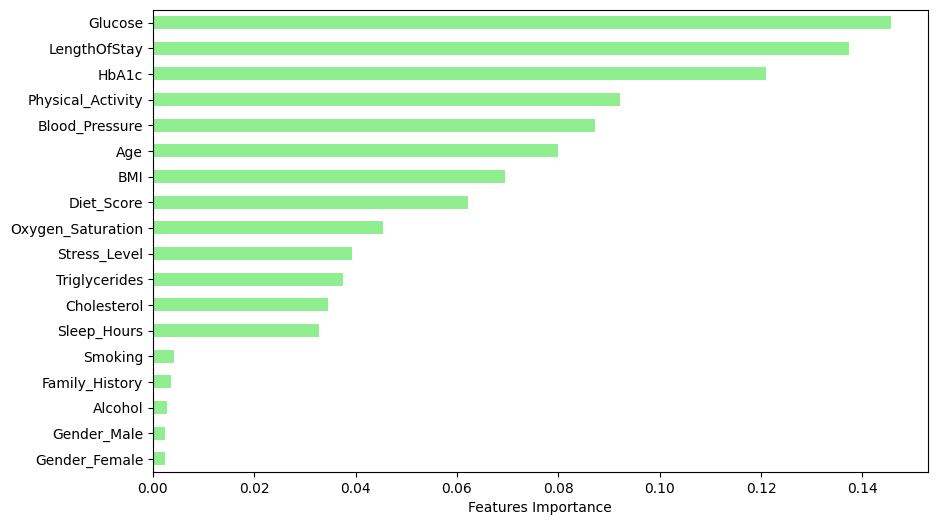

In [34]:
importances = rforest.feature_importances_

# Reconstruct the DataFrame X to get its column names
X_df_for_columns = df.drop('Medical_Condition', axis=1)
feature_names = pd.get_dummies(X_df_for_columns, columns=['Gender']).columns

importances = pd.Series(data=rforest.feature_importances_, index=feature_names)

importances_sorted = importances.sort_values()

importances_sorted.plot(kind='barh', color='lightgreen', figsize=(10,6))
plt.xlabel('Features Importance')
plt.show()